# **Lab 11 - Inverse UQ Part 1: frequentist and Bayesian approaches**


The purpose of inverse UQ is to estimate the parameters of a model given noisy measurements of the system. This is done robustly, i.e., by providing pointwise estimates and by quantifying their uncertainties. Essentially, two main approaches exist:

*   **Frequentist approach**: parameters are estimated by maximizing the likelihood of the observed measurements. Uncertainties are then estimated using asymptotic normality results (Fisher information matrix).

*   **Bayesian approach**: parameters are equipped with a probability distribution (prior). Such distribution is then updated conditionally on the observed measurements using Bayes rule.

Here, we shall explore both approaches by considering their application to models of the form

$$\mathbf{y}_i = f(t_i, \boldsymbol{\mu}) + \boldsymbol{\varepsilon}_i$$

where:
- $i$ denotes the $i$th observation
- $f$ is the parametric model
- $\boldsymbol{\mu}\in\mathbb{R}^p$ are the problem parameters
- $\mathbf{y}\in\mathbb{R}^q$ is the measured quantity at output
- $\boldsymbol{\varepsilon}\in\mathbb{R}^q$ is a centered Gaussian noise, namely $\boldsymbol{\varepsilon}\sim\mathcal{N}(0,\sigma^2 \mathbf{I}_q)$.

We assume to be given $i=1,\dots,n$ measurements.

## Example
The code below illustrates a simple example of a model describing the motion of a projectile. Here, $\boldsymbol{\mu}=(v,\theta)\in\mathbb{R}^2$ are the problem parameters, modeling the initial speed and the launch angle, respectively.

The measurements $\mathbf{y}_i\in\mathbb{R}^2$ refer to the position of the projectile in the $(x,z)$-plane. Such position is only measured at certain time instants $t_i$ and the measurements are corrupted by noise.

We shall assume to know the measurement values (red dots) but not the full trajectory (blue curve) nor the underlying true parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def projectile(mu, t):
  v, theta = mu
  x = v*np.cos(theta)*t
  z = v*np.sin(theta)*t-0.5*9.81*t**2
  return np.stack([x, z], axis = 1)

In [2]:
t = np.linspace(0, 10, 1000) # full time grid
ti = t[[123, 201, 416, 680, 725, 907, 980]] # subgrid: these are the time instants where measurements are made

mu_true = np.array([72, np.pi/3.5]) # true value of the parameters: we pretend not to know them!

np.random.seed(197) # measurements collection and corruption: we assume that these are what we are given
measurements = projectile(mu_true, ti)
measurements = measurements + 10*np.random.randn(*measurements.shape)

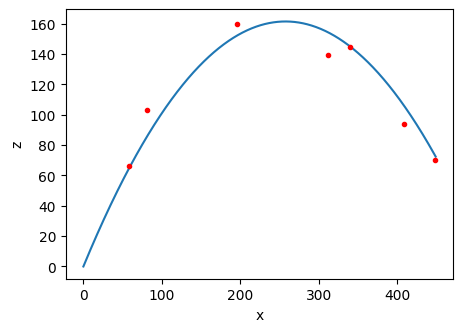

In [3]:
plt.figure(figsize = (5, 3.5))
y_true = projectile(mu_true, t) # full trajectory, not available
plt.plot(*y_true.T)
plt.plot(*measurements.T, '.r')
plt.xlabel("x")
plt.ylabel("z")
plt.show()

## **Frequentist approach**: maximum likelihood estimation (MLE)

For each value of the parameters, $\boldsymbol{\mu}$, the likelihood function $L=L(\boldsymbol{\mu})$ is computed by evaluating the joint-density of the sample on the observed measurements. Here, notice that

$$\mathbf{y}_i\sim\mathcal{N}(f(t_i,\boldsymbol{\mu}),\;\;\sigma^2\mathbf{I}_q)$$

withe samples being $iid$. Thus,

$$L(\boldsymbol{\mu})=\prod_{i=1}^{n}\frac{1}{(2\pi\sigma^{2})^{\frac{q}{2}}}\cdot\exp\left(-\frac{\|\mathbf{y}_i-f(t_i,\boldsymbol{\mu})\|^2}{2\sigma^2}\right).$$

The MLE estimator for $\boldsymbol{\mu}$, denoted as $\boldsymbol{\mu}_{MLE}$, is found by maximizing the above. Equivalently, one can also minimize the so-called negative log-likelihood, $-\log L(\boldsymbol{\mu})$. Up to constants independent of $\boldsymbol{\mu}$, the latter turns out to be equivalent at minimizing the residual sum of squares
$$\text{RSS}(\boldsymbol{\mu})=\sum_{i=1}^{n}\|\mathbf{y}_i-f(t_i,\boldsymbol{\mu})\|^2$$.

In [5]:
def RSS(mu):
  predicted = projectile(mu, ti)
  return np.sum((predicted-measurements)**2)

<mark>**Exercise 1**</mark></br>
Find the MLE for the projectile problem. Plot the corresponding predicted trajectory in comparison with the measurements and the true (unknown) trajectory of the projectile.

 *Hint*: define the RSS, then use the $\textsf{minimize}$ function in $\textsf{scipy.optimize}$.

In [16]:
from scipy.optimize import minimize

results = minimize(RSS, np.ones(mu_true.shape))
print(results)
mu_mle = results.x

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 734.9066764270158
        x: [ 7.175e+01  8.800e-01]
      nit: 13
      jac: [ 7.629e-06  1.297e-04]
 hess_inv: [[ 9.283e-04 -1.930e-06]
            [-1.930e-06  3.219e-07]]
     nfev: 147
     njev: 45


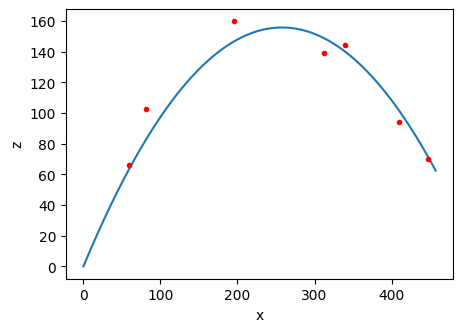

In [17]:
plt.figure(figsize = (5, 3.5))
y_true = projectile(mu_mle, t) # guessed trajectory
plt.plot(*y_true.T)
plt.plot(*measurements.T, '.r')
plt.xlabel("x")
plt.ylabel("z")
plt.show()

In the frequentist approach, uncertainties can be estimated using an asymptotic (reflect on how valid can this be for 7 samples...) normality result which states that an MLE estimator behaves as

$$\boldsymbol{\mu}_{MLE}\approx \mathcal{N}(\boldsymbol{\mu}_*,\; I^{-1}),$$

where $\boldsymbol{\mu}_*$ is the true vector of parameters, while $I$ is the Fisher information matrix. In the setup that we are considering, it can be shown that

$$I^{-1}=\sigma^2 (J^\top J)^{-1}$$

where

- $J\in\mathbb{R}^{nq\times p}$ is the **Jacobian** matrix of the measurements map $\boldsymbol{\mu}\mapsto [f(t_1,\boldsymbol{\mu}),\dots,f(t_n,\boldsymbol{\mu})]$, evaluated at $\boldsymbol{\mu}_{MLE}$. Note that this is referred to the case of additive Gaussians

- $\sigma^2$ is the noise variance, which can be approximated as
$$\sigma^2\approx \hat{\sigma}^2=\frac{\text{RSS}}{nq-p}.$$ The $-p$ bit comes from the fact that we are estimating $p$ parameters.

<mark>**Exercise 2**</mark></br>
Quantify the uncertainties in the estimate obtained at Ex. 1.

In [24]:
projectile(mu_true, np.array([0, 1, 2, 4]))

array([[  0.        ,   0.        ],
       [ 44.89126573,  51.38686674],
       [ 89.78253147,  92.96373348],
       [179.56506294, 146.68746695]])

In [28]:
print(measurements)

[[ 58.5590732   66.12098947]
 [ 81.27543078 102.95794062]
 [195.96914884 159.79575274]
 [311.68249382 139.48694189]
 [339.50903766 144.5836042 ]
 [408.97195543  93.9860339 ]
 [447.60885498  70.32330336]]


In [33]:
n, q = measurements.shape
p = len(mu_mle)

def jacobian(mu):
  J = np.zeros((n, q, p))
  v, theta = mu
  for i in range(n):
    J[i, 0, 0] = np.cos(theta)*ti[i]
    J[i, 0, 1] = -v * np.sin(theta)*ti[i]
    J[i, 1, 0] = np.sin(theta)*ti[i]
    J[i, 1, 1] = v * np.cos(theta)*ti[i]

  return J.reshape((n*q, p))

In [35]:
sigma2 = RSS(mu_mle)/(n*q - p)
J = jacobian(mu_mle)
cov = sigma2 * np.linalg.inv(J.T@J)

In [36]:
np.sqrt(np.diag(cov))

array([0.45139313, 0.00629093])

## **Bayesian approach**: posterior estimation via MCMC

In the Bayesian framework, we start by introducing a prior distribution $\pi_0$ over the parameter space, so that $\boldsymbol{\mu}\sim\pi_0$. Then, the idea is to condition such probability distribution on the observed measurements $\mathbf{Y}=[\mathbf{y}_1,\dots,\mathbf{y}_n]$, simply noting that</br></br>

$$\pi(\boldsymbol{\mu})=\frac{f(\mathbf{Y}\,|\,\boldsymbol{\mu})\pi_0(\boldsymbol{\mu})}{\int f(\mathbf{Y}\,|\,\boldsymbol{\mu}')\pi_0(\boldsymbol{\mu}')d\boldsymbol{\mu}'}.$$

</br>by Bayes' rule, where $\pi$ is now the *posterior* distribution. NB: $f(\mathbf{Y}\,|\,\boldsymbol{\mu}) = L(\boldsymbol{\mu})$ is nothing but the likelihood function!</br></br>


In the general case, $p$ can be fairly large and computing the integral at the denominator can be troublesome. To circumvent this issue, Bayesian techniques often rely on MCMC (Monte Carlo Markov Chain) sampling algorithms, which are special methods designed to directly *sample* from the posterior distribution: in this way, although  the posterior is not available in closed form, it can be explored exhaustively by sampling.

Such techniques, exploit the fact that the posterior is known up to a normalizing constant

$$\pi(\boldsymbol{\mu})\propto f(\mathbf{Y}\,|\,\boldsymbol{\mu})\pi_0(\boldsymbol{\mu}),$$

which is actually enough to construct a sampling algorithm (think, for instance, at the acceptance-rejection method!).

The simplest MCMC algorithm that does this is the Metropolis algorithm, which is based on an accepted-rejection routine. Starting from an initial state $\boldsymbol{\mu}_0$, the latter builds a chain $\boldsymbol{\mu}_0,\dots,\boldsymbol{\mu}_M$ according to the following stepping rule:

- let $\boldsymbol{\mu}_i$ be the current state of the chain
- sample a new candidate state, $\tilde{\boldsymbol{\mu}}_{i+1}$ from a suitable *proposal distribution* $g(\,\cdot\,|\,\boldsymbol{\mu}_i)$, here assumed to be symmetric in its argument and its conditioning state
- accept the candidate with probability
$$\alpha=\min\left\{1,\frac{\pi(\tilde{\boldsymbol{\mu}}_{i+1})}{\pi(\boldsymbol{\mu}_{i})}\right\};$$
if the candidate is accepted, set $\boldsymbol{\mu}_{i+1}=\tilde{\boldsymbol{\mu}}_{i+1}$, otherwise $\boldsymbol{\mu}_{i+1}=\boldsymbol{\mu}_{i}.$
</br></br></br>









NB: MCMC methods do not allow one to directly sample from a desired distribution (differently from the "original" acceptance-rejection method). Instead, they produce a chain of samples that, asymptotically, exhibits the desired distribution. After running an MCMC, it is thus important to:

- remove a first trance of samples, as to ensure that we only keep those in the "asymptotic regime" (burn-in phase)
- "thin" the chain by picking samples every $m$ steps, as to reduce in-sample correlation (the chain is build progressively, so consecutive samples tend to be correlated!)


<mark>**Exercise 3**</mark></br>
Implement Metropolis algorithm for the general case of a model with additive Gaussian noise. For simplicity, assume $\sigma^2$ is known.

In [37]:
import numpy as np

In [73]:
def metropolis(nsim, mu0, prior, proposal_sampler, RSS, sigma2):
    """
    Run the Metropolis MCMC algorithm with a specified prior and proposal.

    Parameters:
    - nsim:      (int)           number of MCMC simulations
    - mu0:       (numpy.ndarray) initial state of the chain (e.g., MLE estimate)
    - prior:     (function)      model prior
    - RSS:       (function)      function computing the residual sum of squares (data misfit)
    - sigma2:    (float)         noise variance

    Returns:
    - chain: MCMC chain of sampled parameters
    - accept_rate: Acceptance rate of the MCMC algorithm
    """
    chain = np.zeros((nsim, len(mu0)))
    chain[0, :] = mu0
    rej = 0
    rss = RSS(mu0)

    for i in range(nsim-1):
        # Sample candidate
        current = chain[i, :]
        candidate = proposal_sampler(current)
        rss_new = RSS(candidate)

        # Metropolis acceptance ratio
        ratio = np.exp(-0.5*(rss_new - rss)/sigma2) * prior(candidate)/prior(current)

        # Accept or reject
        if (np.random.uniform() < ratio):
          chain[i+1, :] = candidate
          rss = rss_new
        else:
          rej += 1
          chain[i+1, :] = current

    accept_rate = 1 - rej / nsim
    return chain, accept_rate

<mark>**Exercise 4**</mark></br>
Use Metropolis algorithm to estimate the problem parameters in the projectile example using a uniform prior, $v\sim\mathcal{U}[0, 200]$ and $\theta\sim\mathcal{U}[0,\pi/2],$ and a Gaussian proposal with a suitable covariance. Use $\hat{\sigma}^2$ to approximate $\sigma^2$. Similarly, use the MLE as initial state for the chain.

After sampling the chain, apply a proper burn-in and thinning to ensure that the autocorrelation in between consecutive samples is sufficiently low.

Remark: we just need the prior up to a constant, since we actually employ its ratio, not its real value.

In [74]:
improper_prior = lambda x: (np.abs(x[0] - 100 ) < 100) + (np.abs(x[1] - np.pi/4.) < np.pi/4.) + 0.
proposal_sampler = lambda x: np.random.multivariate_normal(mean = x, cov = np.diag([5, 0.0001]))

chain, acceptance_rate = metropolis(100000, mu_mle, improper_prior, proposal_sampler, RSS, sigma2)

In [75]:
print(acceptance_rate)

0.16369


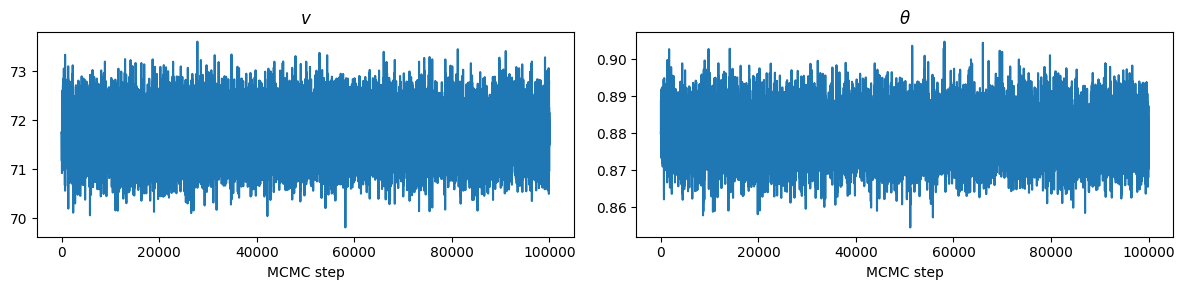

In [76]:
params = ["$v$", "$\\theta$"]
plt.figure(figsize = (12, 3))
for i in range(chain.shape[-1]):
  plt.subplot(1, p, i+1)
  plt.plot(chain[:, i])
  plt.title(params[i])
  plt.xlabel("MCMC step")
plt.tight_layout()

In [85]:
b = 10000
lag = 100
np.corrcoef(chain[b:-lag, 1], chain[b+lag:, 1])

array([[1.       , 0.0164763],
       [0.0164763, 1.       ]])

In [86]:
posterior_samples = chain[b::lag]
posterior_samples.shape

(900, 2)

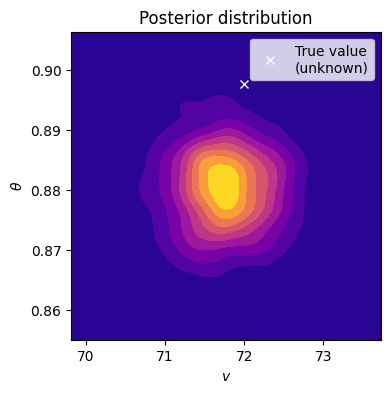

In [87]:
import seaborn as sns
plt.figure(figsize = (4, 4))
sns.kdeplot(x=posterior_samples[:, 0], y=posterior_samples[:, 1], fill=True, cmap="plasma", thresh = 0)
plt.title("Posterior distribution")
plt.xlabel("$v$")
plt.ylabel("$\\theta$")
plt.plot(*mu_true, 'xw', label = 'True value\n(unknown)')
plt.legend()
None

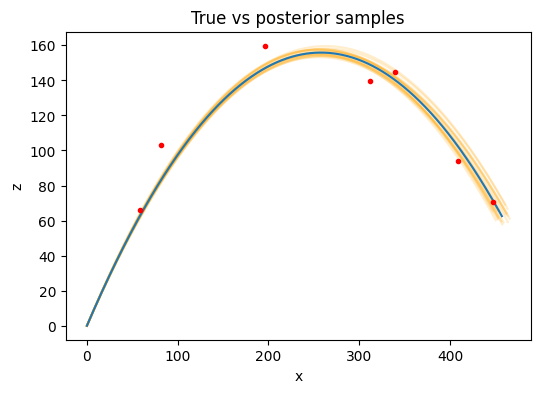

In [88]:
plt.figure(figsize = (6, 4))
for mu_post in posterior_samples[::50]:
  y_post = projectile(mu_post, t)
  plt.plot(*y_post.T, color = 'orange', alpha = 0.2)
plt.plot(*y_true.T)
plt.plot(*measurements.T, '.r')
plt.xlabel("x")
plt.ylabel("z")
plt.title("True vs posterior samples")
plt.show()

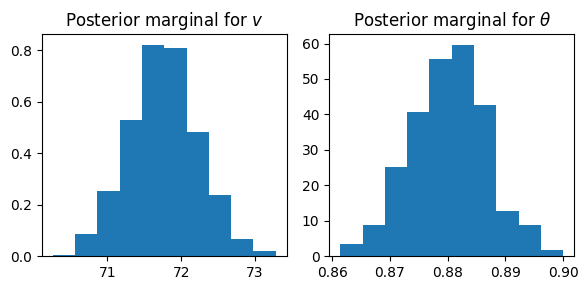

In [89]:
plt.figure(figsize = (6, 3))
for i in range(chain.shape[-1]):
  plt.subplot(1, p, i+1)
  plt.hist(posterior_samples[:, i], bins = 10, density = True)
  plt.title("Posterior marginal for %s" % params[i])
plt.tight_layout()

In [90]:
posterior_samples.mean(axis = 0)

array([71.76291526,  0.8801946 ])

In [91]:
posterior_samples.std(axis = 0, ddof = 1)

array([0.46475849, 0.00655994])

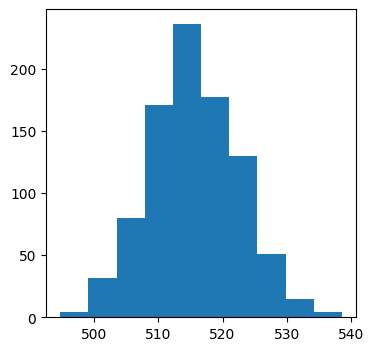

In [92]:
v_post = posterior_samples[:, 0]
th_post = posterior_samples[:, 1]

plt.figure(figsize = (4, 4))
range_post = (v_post**2)*np.sin(2*th_post)/9.81
plt.hist(range_post)
plt.show()

## **More advanced MCMC algorithms using PyMC**
Obviously, libraries already exist. For instance, PyMC allows you to run different MCMC algorithms beyond plain Metropolis (Hamiltonian Monte Carlo, NUTS, etc.). Below is an example of implementation where the NUTS sampler (default in PyMC) is used to address the projectile problem.

A nice visualization of different MCMC algorithms (very helpful to gain some intuition!) can be found here
https://chi-feng.github.io/mcmc-demo/app.html?algorithm=AdaptiveMH&target=banana.



In [93]:
import pymc as pm
import arviz as az

In [95]:
import pytensor.tensor as pt

# Define the PyMC model
with pm.Model() as model:
    # Priors for parameters
    v = pm.Uniform("v", lower=0, upper=200)
    theta = pm.Uniform("theta", lower=0, upper=np.pi/2)

    # Model likelihood
    mu = pt.stack([v*pt.cos(theta)*ti, v*pt.sin(theta)*ti - 0.5*9.81*ti**2], axis = 1)
    cov = sigma2*np.eye(q)
    y_obs = pm.MvNormal("y_obs", mu = mu, cov = cov, observed=measurements)

    # Run MCMC sampler
    trace = pm.sample(
        draws=9000,               # Total number of samples
        initvals={"v": mu_mle[0], "theta": mu_mle[1]},  # Start from LSQ estimates
        tune=1000,                 # Number of tuning steps
        chains=5,
        cores=5,
        return_inferencedata=True  # Return an ArviZ InferenceData object
    )

Output()

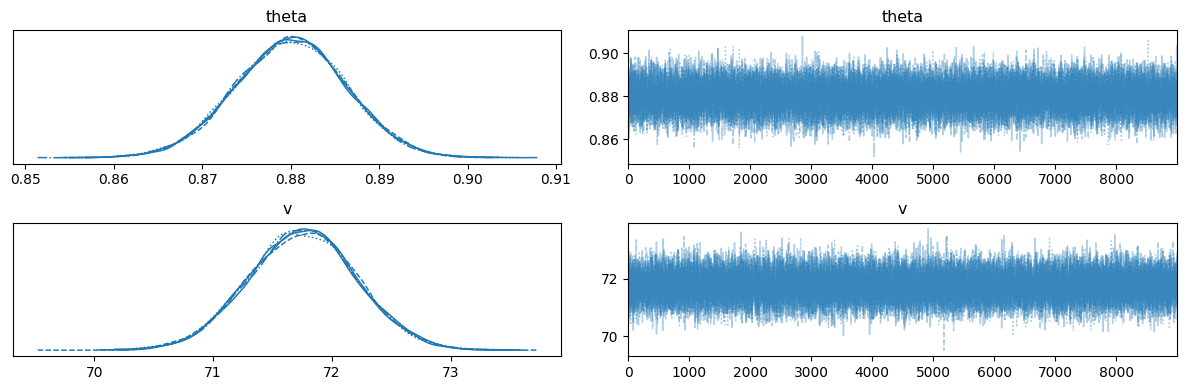

In [96]:
# Analyze and visualize results
az.plot_trace(trace)
plt.tight_layout()

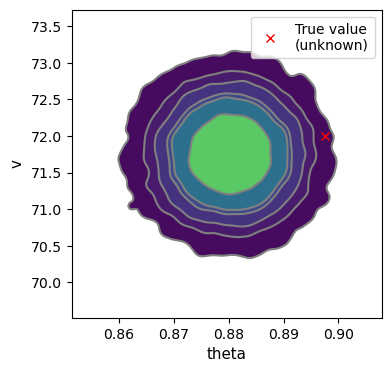

In [97]:
az.plot_pair(trace, kind="kde", kde_kwargs = {'hdi_probs': [0.5, 0.75, 0.8, 0.9, 0.95, 0.99]}, figsize = (4, 4)) # kde, hexbin or scatter
plt.plot(mu_true[1], mu_true[0], 'xr', label = 'True value\n(unknown)')
plt.legend()
plt.show()

In [98]:
# Summary of posterior
summary = az.summary(trace, hdi_prob=0.95)
print("\nPosterior Summary:")
print(summary)


Posterior Summary:
         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
theta   0.880  0.006     0.868      0.892      0.000    0.000   43795.0   
v      71.751  0.455    70.866     72.643      0.002    0.002   44452.0   

       ess_tail  r_hat  
theta   34653.0    1.0  
v       32608.0    1.0  


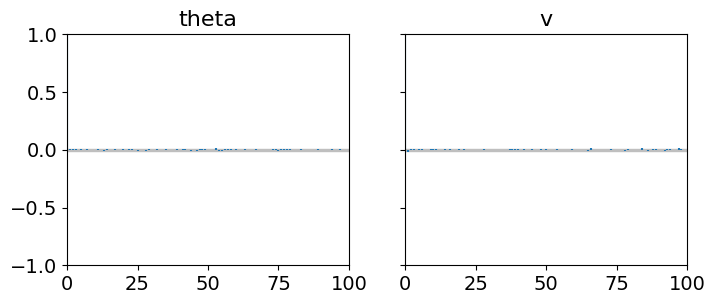

In [99]:
az.plot_autocorr(trace, combined=True, figsize = (8, 3))
None

In [100]:
theta_samples = trace.posterior["theta"].values.flatten()
v_samples = trace.posterior["v"].values.flatten()

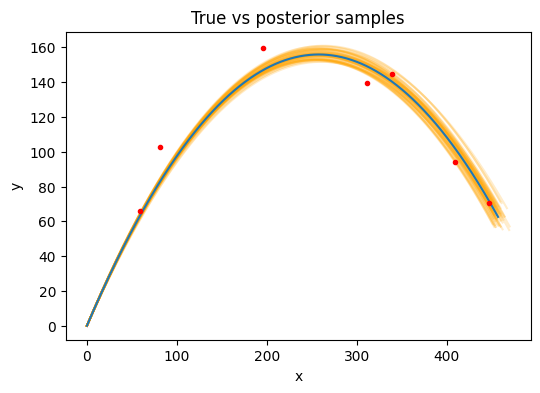

In [101]:
plt.figure(figsize = (6, 4))
for i in range(50):
  post = np.array([v_samples[i], theta_samples[i]])
  y_post = projectile(post, t)
  plt.plot(*y_post.T, color = 'orange', alpha = 0.2)
plt.plot(*y_true.T)
plt.plot(*measurements.T, '.r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("True vs posterior samples")
plt.show()